# Face Recognition Pipeline

## Pipeline Overview

The full pipeline has five steps:

| Step | What happens | Key tool |
|------|-------------|---------|
| **1. Capture** | Get a photo of a face (webcam or file) | OpenCV `VideoCapture` |
| **2. Detect** | Locate the face inside the image, crop it | YOLO `yolov8n.pt` |
| **3. Embed** | Convert the face crop to a 512-D vector | CLIP `clip-ViT-B-32` |
| **4. Store** | Save the vector + metadata to a DB | ChromaDB |
| **5. Verify** | Query the DB with a new face; decide match/no-match | cosine similarity |

**Enrollment** = steps 1-4 (done once, when registering a person).
**Verification** = steps 1-3 then 5 (done at each access attempt).

## Step 1: Capture a Face

In a production system, frames come from a live webcam.
Here we load static portrait images from the `img/` folder to keep the notebook
fully runnable offline, and then show the equivalent webcam code with detailed annotations.

In [ ]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = Path('./img')
names = ['face1', 'face2', 'face3']

face_images = {name: cv2.imread(str(IMG_DIR / f'{name}.jpg')) for name in names}

for name, img in face_images.items():
    assert img is not None, f'Could not load {IMG_DIR}/{name}.jpg'
    print(f'{name}: {img.shape}')

face1: (4000, 6000, 3)
face2: (3852, 4950, 3)
face3: (3840, 5760, 3)


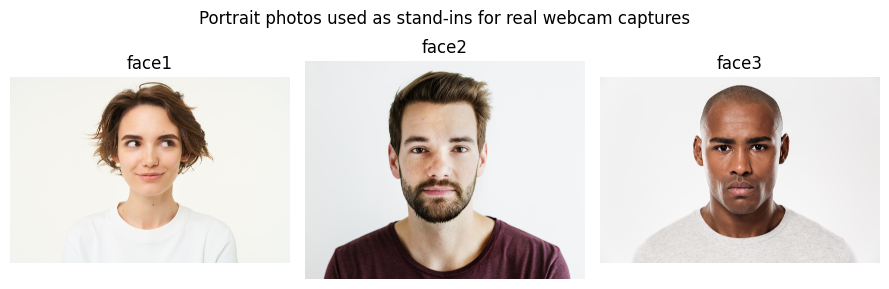

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, name in zip(axes, names):
    ax.imshow(cv2.cvtColor(face_images[name], cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis('off')
plt.suptitle('Portrait photos used as stand-ins for real webcam captures')
plt.tight_layout()
plt.show()

### Webcam Capture Code

> **Note:** The cell below is shown for reference — it requires a physical webcam and
> a GUI display. Do not run it in a headless/cloud environment.

In the full project this logic lives in `authentication.py → capture_student_authentication()`.

In [ ]:
# ⚠️ REFERENCE ONLY — requires webcam + GUI display
# This is the pattern used by computer-vision/implementation/src/authentication.py

def capture_faces_from_webcam(n_captures: int = 5) -> list[np.ndarray]:
    captures = []
    cap = cv2.VideoCapture(0)  # 0 = first camera

    while len(captures) < n_captures:
        ret, frame = cap.read()
        if not ret:
            break

        # Quality check 1: brightness
        # A mean pixel value outside 50–200 means too dark or overexposed.
        brightness = frame.mean()
        if not (50 < brightness < 200):
            cv2.putText(frame, 'Bad lighting!', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.imshow('Capture', frame)
            cv2.waitKey(100)
            continue

        # Quality check 2: blur (Laplacian variance)
        # A blurry frame has low variation in second derivative.
        # Threshold of 100 is a typical rule of thumb.
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        if blur_score < 100:
            cv2.putText(frame, 'Too blurry!', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.imshow('Capture', frame)
            cv2.waitKey(100)
            continue

        captures.append(frame.copy())
        cv2.putText(frame, f'Captured {len(captures)}/{n_captures}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.imshow('Capture', frame)
        cv2.waitKey(500)  # brief pause between captures

    # Releases the camera so other applications can use it.
    cap.release()
    # Closes all GUI windows created by cv2.imshow().
    cv2.destroyAllWindows()
    return captures

# _ = capture_faces_from_webcam()

## Step 2: Detect the Face with YOLO

YOLO's general model (`yolov8n.pt`) detects people as **class 0**.
We take the highest-confidence person box and crop it as the face region.

For a real deployment, use `yolov8n-face.pt` which is fine-tuned specifically
on faces and returns tighter boxes around the face rather than the full body.

In [ ]:
from ultralytics import YOLO

# Load the nano model (smallest/fastest).
# Downloads ~6 MB on first run.
detector = YOLO('yolov8n.pt')
print('Detector loaded')

Detector loaded


In [ ]:
def detect_and_crop_face(img: np.ndarray, padding: int = 20) -> np.ndarray:
    h, w = img.shape[:2]

    # Run inference; suppress console output with verbose=False.
    results = detector(img, verbose=False)
    boxes = results[0].boxes

    # Filter to class 0 (person), keep the highest-confidence detection.
    # On photos with no detected person, fall back to the whole image.
    best_box = None
    best_conf = 0
    for box in boxes:
        if int(box.cls[0]) == 0 and float(box.conf[0]) > best_conf:
            best_conf = float(box.conf[0])
            best_box = box.xyxy[0].cpu().numpy().astype(int)

    if best_box is None:
        # No person detected — use the whole image as the 'face'.
        # In a production system you would reject this frame instead.
        return img

    x1, y1, x2, y2 = best_box
    # Add padding around the box, clamped to image boundaries.
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    return img[y1:y2, x1:x2]


face_crops = {name: detect_and_crop_face(face_images[name]) for name in names}
for name, crop in face_crops.items():
    print(f'{name}: crop shape = {crop.shape}')

face1: crop shape = (3835, 3845, 3)
face2: crop shape = (3725, 4427, 3)
face3: crop shape = (3705, 4606, 3)


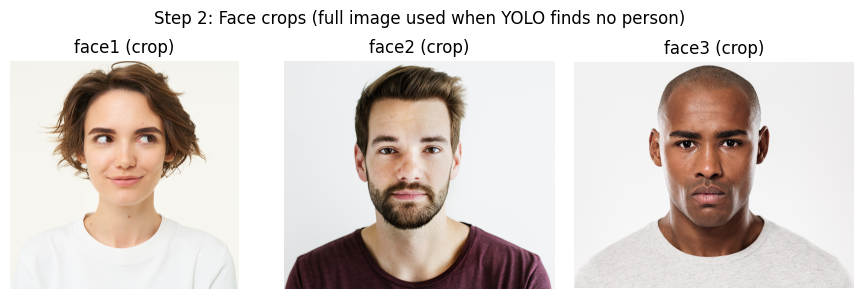

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, name in zip(axes, names):
    ax.imshow(cv2.cvtColor(face_crops[name], cv2.COLOR_BGR2RGB))
    ax.set_title(f'{name} (crop)')
    ax.axis('off')
plt.suptitle('Step 2: Face crops (full image used when YOLO finds no person)')
plt.tight_layout()
plt.show()

## Step 3: Extract a Feature Embedding with CLIP

We pass each face crop through the CLIP image encoder to get a 512-D vector.

Key properties we verify:
- **Shape**: should be `(512,)`
- **Norm**: CLIP outputs are NOT automatically L2-normalised — we normalise them
  before storing so that cosine distance = 1 − dot product (faster math).

In [ ]:
from sentence_transformers import SentenceTransformer

clip_model = SentenceTransformer('clip-ViT-B-32')
print(f'Embedding dimension: {clip_model.get_sentence_embedding_dimension()}')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /home/avidaldo/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: None


In [ ]:
def embed_face(bgr_crop: np.ndarray) -> np.ndarray:
    # Convert BGR (OpenCV default) → RGB (PIL/CLIP default).
    rgb = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)
    emb = clip_model.encode(pil_img)   # numpy float32 array, shape (512,)
    # L2-normalise so that dot product == cosine similarity.
    emb = emb / np.linalg.norm(emb)
    return emb

for name in names:
    emb = embed_face(face_crops[name])
    print(f'{name}: shape={emb.shape}  norm={np.linalg.norm(emb):.6f}  (should be ~1.0 after normalisation)')

face1: shape=(512,)  norm=1.000000  (should be ~1.0 after normalisation)
face2: shape=(512,)  norm=1.000000  (should be ~1.0 after normalisation)
face3: shape=(512,)  norm=1.000000  (should be ~1.0 after normalisation)


## Step 4: Store Embeddings in ChromaDB

We create a persistent ChromaDB collection and insert one embedding per student.
The metadata includes the student name and enrollment timestamp.

In [ ]:
import chromadb
import datetime

# PersistentClient saves data to disk — survives notebook restarts.
db_path = './face_db'
db_client = chromadb.PersistentClient(path=db_path)

# Delete the collection if it already exists (clean slate for this demo).
try:
    db_client.delete_collection('enrolled_faces')
    print('Old collection deleted')
except Exception:
    pass

# cosine distance is the right metric for L2-normalised CLIP embeddings.
face_collection = db_client.create_collection(
    name='enrolled_faces',
    metadata={'hnsw:space': 'cosine'}
)
print('Collection ready')

Old collection deleted
Collection ready


In [ ]:
# Enroll all three students
for name in names:
    emb = embed_face(face_crops[name])
    face_collection.add(
        ids        = [f'{name}_enroll_001'],
        embeddings = [emb.tolist()],
        metadatas  = [{'student': name,
                        'enrolled_at': datetime.datetime.now().isoformat(),
                        'source': 'static_image_demo'}]
    )

print(f'Enrolled {face_collection.count()} face(s) in ChromaDB')

Enrolled 3 face(s) in ChromaDB


## Step 5: Verify Identity (Similarity Search)

At verification time, the student presents a new photo.
We embed it and query the database for the closest stored embedding.

**Decision rule**: if the top match has cosine_similarity ≥ threshold → identity confirmed.

Tuning the threshold:
- Too high (e.g. 0.99) → many false rejections (security-oriented)
- Too low (e.g. 0.5) → easy to spoof with any similar-looking person (convenience-oriented)
- The project uses **0.85** as a balanced default for academic authentication.

In [ ]:
VERIFICATION_THRESHOLD = 0.85

def verify_identity(query_crop: np.ndarray, student_name: str | None = None) -> dict:
    query_emb = embed_face(query_crop)

    # Optionally narrow the search to a specific student (for 1:1 verification).
    where_clause = {'student': student_name} if student_name else None

    results = face_collection.query(
        query_embeddings = [query_emb.tolist()],
        n_results = 3,
        where = where_clause,
        include = ['metadatas', 'distances'],
    )

    top_id   = results['ids'][0][0]
    top_dist = results['distances'][0][0]
    top_meta = results['metadatas'][0][0]
    # ChromaDB returns cosine DISTANCE (0 = identical, 2 = opposite).
    # Convert to similarity: similarity = 1 − distance.
    similarity = 1.0 - top_dist

    return {
        'verified': similarity >= VERIFICATION_THRESHOLD,
        'similarity': similarity,
        'matched_id': top_id,
        'matched_student': top_meta['student'],
        'all_results': list(zip(results['ids'][0], [1-d for d in results['distances'][0]]))
    }

## Enrollment + Verification Demo

We query each student's own enrolled image (expect match),
then query student_a's image but ask for student_b (expect no-match).

In [ ]:
print('=== Same-person queries (should verify) ===')
for name in names:
    result = verify_identity(face_crops[name])
    status = '✓ VERIFIED' if result['verified'] else '✗ REJECTED'
    print(f'{name} → matched={result["matched_student"]:12s}  similarity={result["similarity"]:.4f}  {status}')

print()
print('=== Cross-person query (should reject) ===')
result = verify_identity(face_crops['face1'], student_name='face2')
status = '✓ VERIFIED' if result['verified'] else '✗ REJECTED (correct!)'
print(f'student_a queried against student_b → similarity={result["similarity"]:.4f}  {status}')

=== Same-person queries (should verify) ===
face1 → matched=face1         similarity=1.0000  ✓ VERIFIED
face2 → matched=face2         similarity=1.0000  ✓ VERIFIED
face3 → matched=face3         similarity=1.0000  ✓ VERIFIED

=== Cross-person query (should reject) ===
student_a queried against student_b → similarity=0.7639  ✗ REJECTED (correct!)


In [ ]:
# Visualise similarities as a heatmap
n = len(names)
sim_matrix = np.zeros((n, n))
for i, query_name in enumerate(names):
    q_emb = embed_face(face_crops[query_name])
    for j, stored_name in enumerate(names):
        results = face_collection.query(
            query_embeddings=[q_emb.tolist()],
            n_results=1,
            where={'student': stored_name},
            include=['distances']
        )
        sim_matrix[i, j] = 1 - results['distances'][0][0]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_yticklabels(names)
ax.set_xlabel('Stored (enrolled)')
ax.set_ylabel('Query')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.3f}', ha='center', va='center', fontsize=10,
                color='white' if sim_matrix[i,j] < 0.4 or sim_matrix[i,j] > 0.85 else 'black')
ax.axhline(0.5, color='grey', lw=0.5, ls='--')
ax.set_title('Query-vs-stored cosine similarity\n(diagonal = same person)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Connection to the Full Project

Each step above maps directly to a module in `computer-vision/implementation/src/`:

| Step | This notebook | Project module |
|------|--------------|----------------|
| Capture | `capture_faces_from_webcam()` | `authentication.py` → `capture_student_authentication()` |
| Detect + crop | `detect_and_crop_face()` using `yolov8n.pt` | `face_detector.py` → `detect_faces()` |
| Embed | `embed_face()` using `clip-ViT-B-32` | `feature_extractor.py` → `extract_features()` |
| Store | `face_collection.add()` | `vector_database.py` → `add_face()` |
| Verify | `face_collection.query()` + threshold | `similarity_search.py` → `search_by_face_image()` |

The project adds production features this notebook omits:
- **Multiple enrollment captures** per student (5–10 frames) with quality checks
- **Structured configuration** via `config/config.yaml` (thresholds, model paths, etc.)
- **JSON authentication reports** and saved face crops for audit trails
- A top-level `main.py` that wires all modules together

## Cleanup

In [ ]:
import shutil

# Remove the demo database
shutil.rmtree('face_db', ignore_errors=True)
print('Cleanup done')